In [1]:
import matplotlib.pyplot as plt
import numpy as np

from utils.utils import (fast_down_sample, fast_up_sample, 
                         make_image_collection, read_image_collection,
                         read_config, 
                         class_to_artificial, artificial_to_rgb, 
                         class_to_vegetal, vegetal_to_rgb,
                         class_to_rgb,
                         fast_down_sample, fast_up_sample)

from pprint import pprint
from pathlib import Path

In [2]:
# massage this to get the correct project root path (e.g. /../xxxx/myProjectName/)
root_dir = Path().resolve().parents[0]
conf = read_config(file_path=root_dir / 'config' /'config.yml', root_dir=root_dir) 


Configuration read from /workspaces/flairimages/config/config.yml
file locations are:
{'config': PosixPath('/workspaces/flairimages/config'),
 'dataset': PosixPath('/workspaces/flairimages/data/test'),
 'files_csv': PosixPath('/workspaces/flairimages/data/test/testdataset.csv'),
 'files_df': PosixPath('/workspaces/flairimages/data/test/testdataset.pkl'),
 'image_collection': PosixPath('/workspaces/flairimages/data/test/testimagecollection.npy'),
 'image_collection_index': PosixPath('/workspaces/flairimages/data/test/testimagecollectionindex.npy'),
 'metadata': PosixPath('/workspaces/flairimages/data/flair-1_metadata_aerial.json'),
 'outputs': PosixPath('/workspaces/flairimages/outputs')}


res.shape:(100, 64, 64, 8)


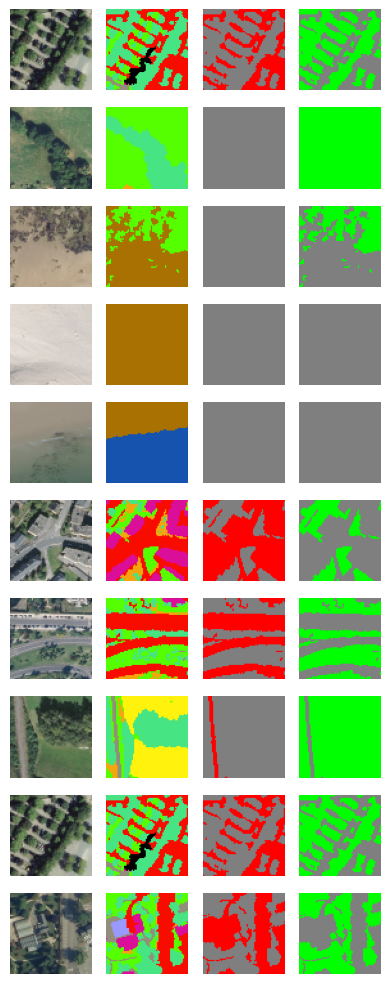

In [14]:
# test the image collection apparent consistency
res = read_image_collection(conf=conf)
print(f"res.shape:{res.shape}")

plt.figure(figsize=(4,10))
for i, index in enumerate(np.random.randint(low=0, high=res.shape[0], size=10)):
    img= res[index,:,:,:3]
    msk = res[index,:,:,-3]
    artificial = res[index,:,:,-2]
    vegetal = res[index,:,:, -1]

    plt.subplot(10, 4, 4*i+1)
    plt.axis('off')
    plt.imshow(img)
    #
    plt.subplot(10, 4, 4*i+2)
    plt.axis('off')
    plt.imshow(class_to_rgb(arr=msk,config=conf))
    
    plt.subplot(10, 4, 4*i+3)
    plt.axis('off')
    plt.imshow(artificial_to_rgb(arr=artificial, conf=conf))
    
    plt.subplot(10, 4, 4*i+4)
    plt.axis('off')
    plt.imshow(vegetal_to_rgb(arr=vegetal, conf=conf))
    
    plt.tight_layout()
    

In [10]:
# print memory usage
print(res.shape)
print(f"{res.nbytes:,.0f} bytes")


(100, 64, 64, 8)
3,276,800 bytes
